### 🚢 Titanic Project - Data Analysis and Machine Learning

This project explores the Titanic dataset and builds a predictive model to estimate passenger survival.

#### Steps:
- Exploratory Data Analysis (EDA)
- Data cleaning
- Feature engineering
- Model training
- Model evaluation

### 📚 1. Import libraries

In [68]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Machine Learning tools
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### 📥 2. Load dataset

In [69]:
# Load dataset from seaborn
titanic = sns.load_dataset('titanic')

# Preview first rows
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [70]:
# General information about the dataset
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [71]:
# Statistical summary of numerical columns
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### 🔎 3. Exploratory Data Analysis (EDA)

#### Survival distribution

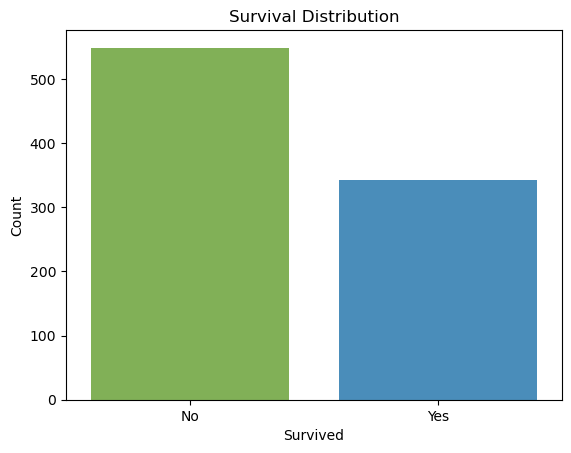

In [72]:
# Count of survivors vs non-survivors
sns.countplot(data=titanic, x='survived', hue='survived', palette={0: '#80bf48', 1: '#3790cd'}, legend=False)
plt.title('Survival Distribution')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

Survival by gender

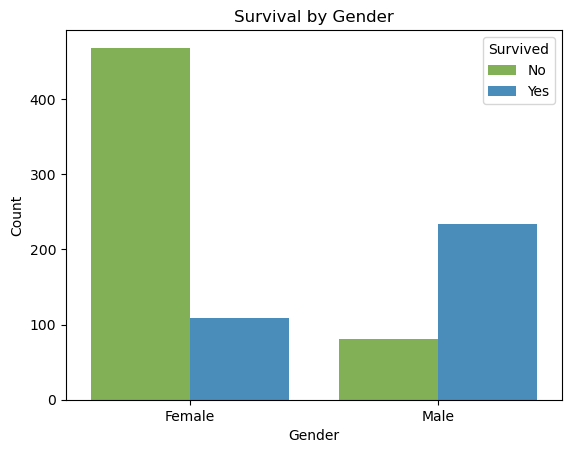

In [73]:
# Compare survival between male and female passengers
sns.countplot(data=titanic, x='sex', hue='survived', palette=['#80bf48', '#3790cd'])
plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks([0, 1], ['Female', 'Male'])
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

Age distribution

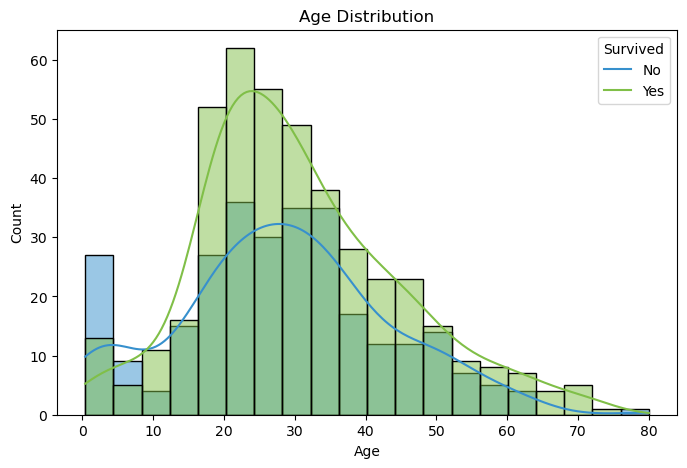

In [74]:
# Distribution of age with survival distinction
plt.figure(figsize=(8,5))
sns.histplot(data=titanic, x='age', hue='survived', bins=20, palette=['#80bf48', '#3790cd'],kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

Passenger class vs survival

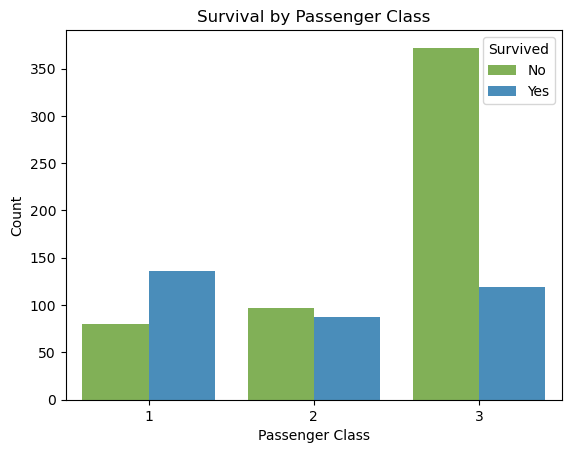

In [75]:
# Analyze survival based on passenger class
sns.countplot(data=titanic, x='pclass', hue='survived', palette=['#80bf48', '#3790cd'])
plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

Correlation heatmap

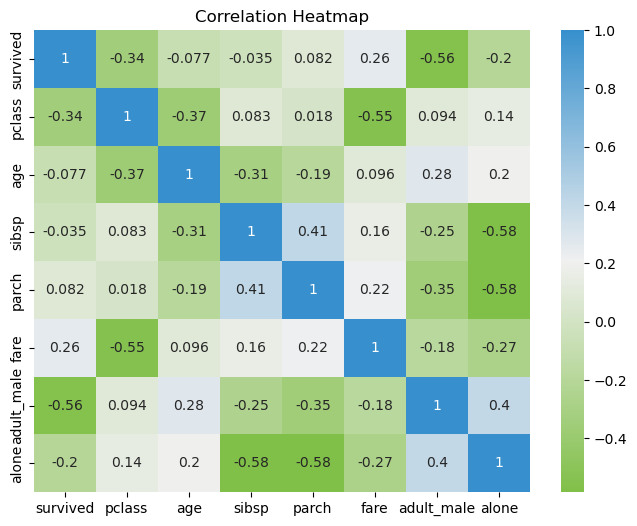

In [76]:
from matplotlib.colors import LinearSegmentedColormap

# Create custom colormap
custom_cmap = LinearSegmentedColormap.from_list(
    'custom_palette',
    ['#80bf48', '#f0f0f0', '#3790cd']
)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    titanic.corr(numeric_only=True),
    annot=True,
    cmap=custom_cmap
)

plt.title('Correlation Heatmap')
plt.show()

### 🧹 4. Data Cleaning

Missing values

In [77]:
# Create a fresh copy (important for reproducibility)
titanic_clean = sns.load_dataset('titanic')

# Check missing values
titanic_clean.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Fill missing values

In [78]:
# Fill numerical missing values with median (more robust than mean)
titanic_clean['age'] = titanic_clean['age'].fillna(titanic_clean['age'].median())

Fill categorical missing values

In [79]:
# Fill categorical missing values with mode
titanic_clean['embarked'] = titanic_clean['embarked'].fillna(
    titanic_clean['embarked'].mode()[0]
)

Drop irrelevant columns

In [80]:
# Drop columns not useful for modeling
titanic_clean = titanic_clean.drop(columns=[
    'deck', 'embark_town', 'alive', 'class', 'who'
])

### 🧠 5. Feature Engineering

Family size

In [81]:
# Family size feature
titanic_clean['family_size'] = titanic_clean['sibsp'] + titanic_clean['parch'] + 1

Is alone

In [82]:
# Is alone feature
titanic_clean['is_alone'] = (titanic_clean['family_size'] == 1).astype(int)

### 🤖 6. Model Training

Define features and target

In [83]:
X = titanic_clean[['pclass', 'sex', 'age', 'fare', 'family_size', 'is_alone']]
y = titanic_clean['survived']

Train-test split

In [84]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Train model

In [85]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

numeric_features = ['pclass', 'age', 'fare', 'family_size', 'is_alone']
categorical_features = ['sex']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'fare',
                                                   'family_size', 'is_alone']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first'))]),
                                                  ['sex'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [86]:
X_train.isnull().sum()

pclass         0
sex            0
age            0
fare           0
family_size    0
is_alone       0
dtype: int64

### 📏 7. Model Evaluation

Predictions

In [87]:
# Generate predictions on test data
y_pred = model.predict(X_test)

Accuracy

In [88]:
# Calculate accuracy score
accuracy_score(y_test, y_pred)

0.8100558659217877

Classification report

In [89]:
# Detailed performance metrics
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.71      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179



Confusion matrix

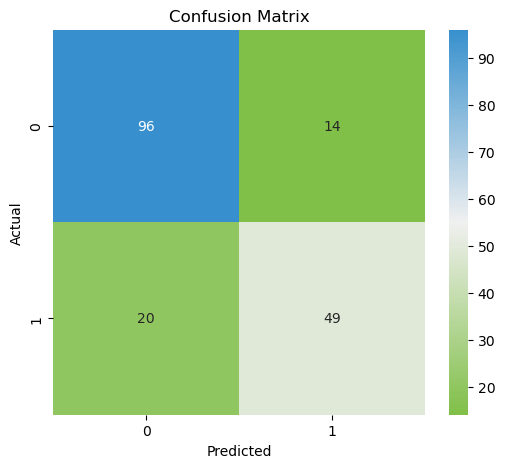

In [90]:
# Create custom colormap
custom_cmap = LinearSegmentedColormap.from_list(
    'custom_palette',
    ['#80bf48', '#f0f0f0', '#3790cd']
)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap=custom_cmap)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()